In [2]:
using Distributions
using MLUtils: DataLoader
using LinearAlgebra
using AbstractGPs
using CSV
using DataFrames
import ComponentArrays: ComponentArray
using DataInterpolations

using CairoMakie
using ColorSchemes

include("src/rgp.jl")
include("src/battModel.jl")
using .RecursiveGPs
using .battModel

# Profile 2

In [3]:
df_p2 = CSV.read("data/profile2.csv", DataFrame);

In [46]:
## Train
N_points = size(df_p2)[1]
soc_test = df_p2[!, "soc"][1:N_points]
i_test = df_p2[!, "i"][1:N_points]

v_test = df_p2[!, "v"][1:N_points];
batch_size = 1
data = DataLoader((
    x=(
    soc = soc_test,
    i = i_test
    ), 
    y=v_test
    ),
    batchsize=batch_size, shuffle=false
    );

In [55]:
l_ocv = 0.2
σ_ocv = 0.1

l_r = 0.2
σ_r = 0.1

σ_f1 = 0.01
σ_f2 = 0.00005


limit_basis_ocv = [0, 1]
step_basis_ocv = 0.01
X_basis_ocv = collect(limit_basis_ocv[1]:step_basis_ocv:limit_basis_ocv[2])
n_basis = size(X_basis_ocv)[1]
X_basis_r = collect(limit_basis_ocv[1]:step_basis_ocv:limit_basis_ocv[2])

gp_ocv = gp_ocv = GP(
    LinearKernel() +
    σ_ocv * with_lengthscale(SEKernel(), l_ocv)
)
rgp_ocv = RGPModel(gp_ocv, σ_f1, X_basis_ocv);

gp_r = GP(σ_r * with_lengthscale(SEKernel(), l_r))
rgp_r = RGPModel(gp_r, σ_f2, X_basis_r)

batt = BATTModel(rgp_ocv, rgp_r);


In [56]:
for (n, batch) in enumerate(data)
    battery_learn!(batt, batch)
end


In [57]:
limit_predict = [0, 1]
step_predict = 0.01

X_predict_soc = collect(limit_predict[1]:step_predict:limit_predict[2])
rgp_ocv = batt.rgp_ocv
rgp_r = batt.rgp_r

μ_ocv = predict(rgp_ocv, X_predict_soc).μ
Σ_ocv = predict(rgp_ocv, X_predict_soc).Σ
var_ocv = sqrt.(abs.(diag(Σ_ocv)));
μ_r = predict(rgp_r, X_predict_soc).μ;
Σ_r = predict(rgp_r, X_predict_soc).Σ;
var_r = sqrt.(abs.(diag(Σ_r)));

V_p = predict(rgp_ocv, soc_test[1:50:end]).μ +  i_test[1:50:end].* predict(rgp_r, soc_test[1:50:end]).μ
V_r = v_test[1:50:end];

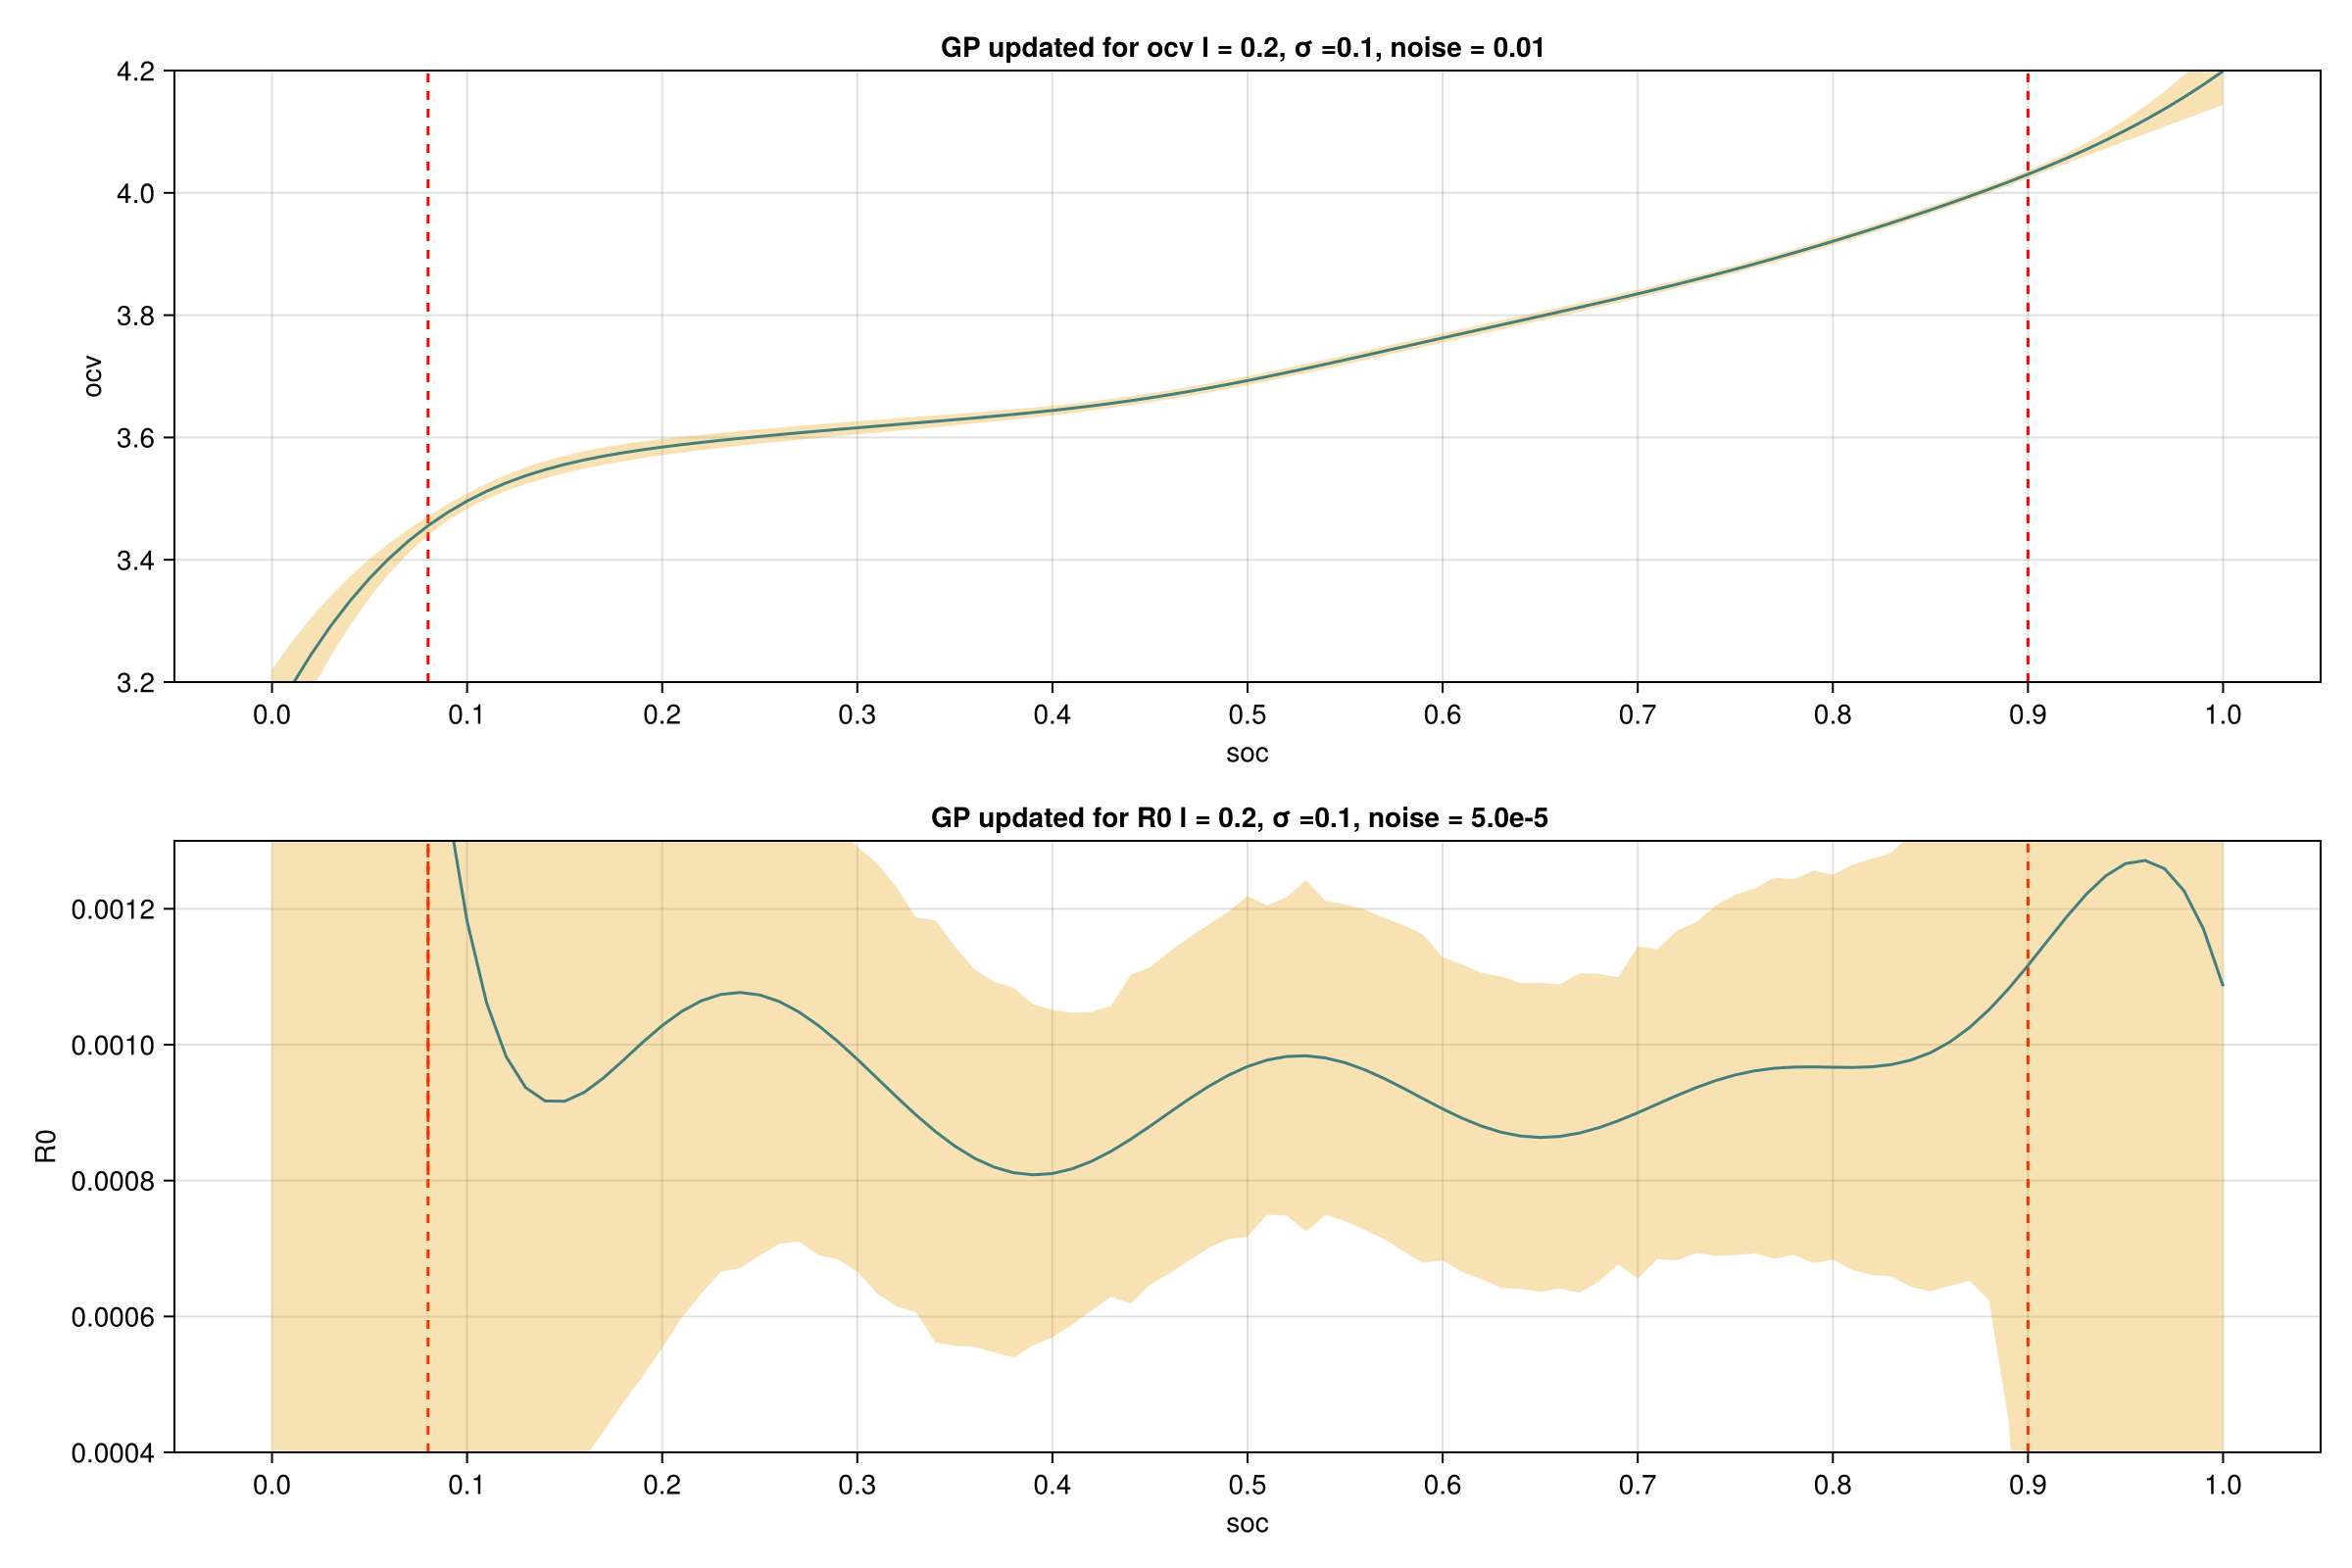

CairoMakie.Screen{IMAGE}


In [58]:
##  function
fig = Figure(size = (1200, 800))
ax1 = Axis(fig[1, 1], title="GP updated for ocv l = $(l_ocv), σ =$(σ_ocv), noise = $(σ_f1) ", xlabel="soc", ylabel="ocv", xticks=limit_predict[1]:0.1:limit_predict[2])
lines!(ax1, X_predict_soc, μ_ocv, label="OCV aprox")
vlines!(ax1, [minimum(soc_test), maximum(soc_test) ], color=:red, linestyle=:dash, label="Outsite test data")
ylims!(ax1, 3.2, 4.2)
band!(ax1, X_predict_soc, μ_ocv - 2var_ocv, μ_ocv + 2var_ocv; label="uncertainty band", color=(Makie.wong_colors()[2], 0.3))

ax2 = Axis(fig[2, 1], title="GP updated for R0 l = $(l_r), σ =$(σ_r), noise = $(σ_f2)  ", xlabel="soc", ylabel="R0", xticks=limit_predict[1]:0.1:limit_predict[2])
lines!(ax2, X_predict_soc, μ_r, label="R0 aprox")
vlines!(ax2, [minimum(soc_test), maximum(soc_test) ], color=:red, linestyle=:dash, label="Outsite test data")
lines!(ax2, [minimum(soc_test), minimum(soc_test)], [minimum(μ_r), maximum(μ_r)], color=:red, linestyle=:dash, label="Outsite test data")
band!(ax2, X_predict_soc, μ_r - 2var_r, μ_r + 2var_r; label="uncertainty band", color=(Makie.wong_colors()[2], 0.3))

ylims!(ax2,0.0004, 0.0013)

#ax3 = Axis(fig[3,1], title = "SOC histogram", xticks=limit_predict[1]:0.1:limit_predict[2])
#hist!(ax3, soc_test; bins = 20, color =:gray)
#xlims!(ax3, 0, 1)


#save("pictures/profile2/ocv_parameters/profile2_r_l$(l_ocv)_sigma$(σ_ocv)_noise$(σ_f1)_n_basis_$(n_basis)_batch_size$(batch_size)_new_noise.png", fig)
display(fig)

# Synthetic

In [3]:
df_with_rc = CSV.read("data/output_data_without_rc.csv", DataFrame)
df_profile = CSV.read("data/profile.csv", DataFrame);
df_ocv = CSV.read("data/ocv.csv", DataFrame);

In [4]:
focv = LinearInterpolation(df_ocv.ocv, df_ocv.soc; extrapolation=ExtrapolationType.Constant);

In [5]:
N_points = size(df_with_rc.soc)[1]
X_soc = df_with_rc.soc[1:N_points]
X_i = df_profile.i[1:N_points]
Y_v = df_with_rc.voltage[1:N_points];
batch_size = 1
data = DataLoader((
    x=(
    soc = X_soc,
    i = X_i
    ), 
    v=Y_v
    ),
    batchsize=batch_size, shuffle=false
    );

In [6]:
l_ocv = 0.4

σ_ocv = 0.1

σ_f1 = 0.01

limit_basis_ocv = [0, 1]
step_basis_ocv = 0.01

X_basis_ocv = collect(limit_basis_ocv[1]:step_basis_ocv:limit_basis_ocv[2]);
n_basis = size(X_basis_ocv)[1]
gp_ocv = GP(
    LinearKernel() +
    σ_ocv * with_lengthscale(SEKernel(), l_ocv)
)
rgp_ocv = RGPModel(gp_ocv, σ_f1, X_basis_ocv)
R0 = 15e-3;

In [ ]:
animation = DataFrame(step=Int[], μ=Vector{Float64}[], σ=Vector{Float64}[] )
ani_step = 10
error_step = 100
limit_predict = [0, 1]
step_predict = 0.01

X_predict_soc = collect(limit_predict[1]:step_predict:limit_predict[2])
errors_test = Float64[]
errors_train = Float64[]

### Augmented Kalman filter
for (n, batch) in enumerate(data)
    ocv_i = batch.v .- batch.x.i .* R0 
    learn!(rgp_ocv,batch.x.soc, ocv_i)
    

    if n%error_step == 0
        prediction = predict(rgp_ocv, batch.x.soc)
        error_test = sqrt(mean((focv.t[1:10:end] -  predict(rgp_ocv, focv.t[1:10:end]).μ).^2))
        error_train = sqrt(mean((focv(batch.x.soc) - prediction.μ).^2))
        push!(errors_test, error_test)
        push!(errors_train, error_train)
        push!(animation, (step=n, μ=prediction.μ, σ=sqrt.(abs.(diag(prediction.Σ)))))
    end

end


(; μ, Σ) = predict(rgp_ocv, X_predict_soc)
σ = sqrt.(abs.(diag(Σ)));


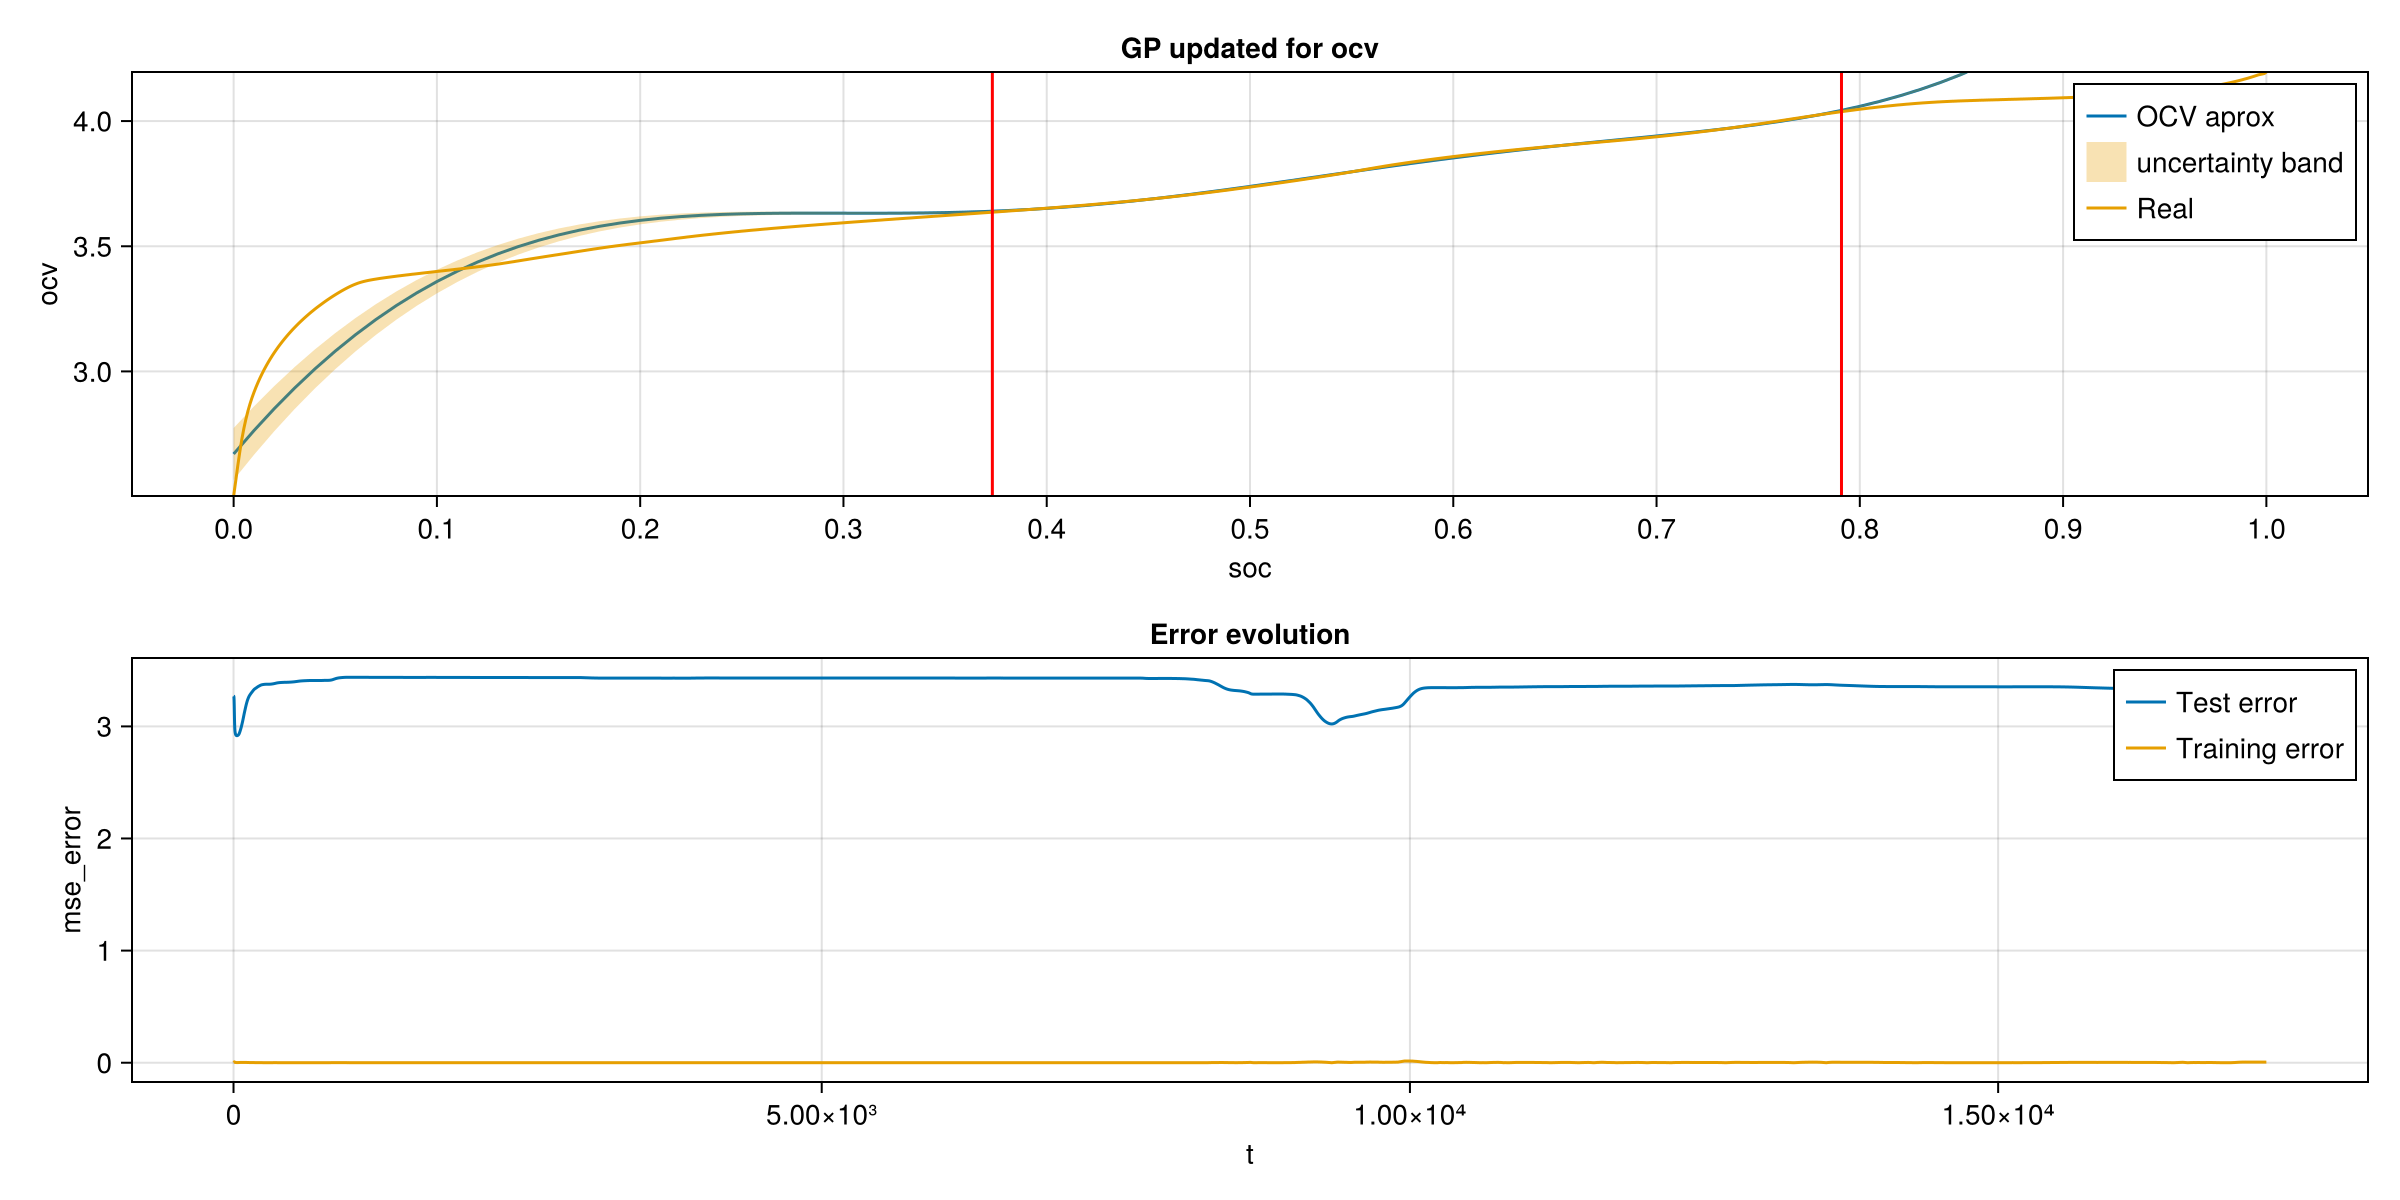

CairoMakie.Screen{IMAGE}


In [63]:
fig = Figure(size = (1200, 600))
ax1 = Axis(fig[1, 1], title="GP updated for ocv", xlabel="soc", ylabel="ocv", xticks=limit_predict[1]:0.1:limit_predict[2])

lines!(ax1, X_predict_soc, μ, label="OCV aprox")
band!(ax1, X_predict_soc, μ - 2σ, μ + 2σ; label="uncertainty band", color=(Makie.wong_colors()[2], 0.3))

lines!(ax1,focv.t,focv.u,label="Real")
ylims!(ax1, minimum(focv.u),  maximum(focv.u))
vlines!(ax1, [minimum(X_soc), maximum(X_soc)], color = :red)

ax2 = Axis(fig[2, 1], title="Error evolution", xlabel="t", ylabel="mse_error")

lines!(ax2, errors_test, label="Test error")
lines!(ax2, errors_train, label="Training error")

save("pictures/batch_size/synthetic_l$(l_ocv)_sigma$(σ_ocv)_noise$(σ_f1)_n_basis_$(n_basis)_batch_size$(batch_size).png", fig)
axislegend(ax1)
axislegend(ax2)
display(fig)

In [ ]:
fig = Figure(size = (1200, 600))
ax1 = Axis(fig[1, 1], title="GP updated for ocv", xlabel="soc", ylabel="ocv", xticks=limit_predict[1]:0.1:limit_predict[2])

# Static elements
lines!(ax1, focv.t, focv.u, label="Real", color=:black)
vlines!(ax1, [minimum(X_soc), maximum(X_soc)], color = :red)
ylims!(ax1, minimum(focv.u), maximum(focv.u))
ax1.title = "GP updated for ocv"
axislegend(ax1)

# Dynamic elements initialized with first frame
gp_line = lines!(ax1, X_predict_soc, animation.μ[1], label="OCV approx", color=:blue)

band_plot = band!(ax1, X_predict_soc, animation.μ[1] - 2*animation.σ[1], animation.μ[1] + 2*animation.σ[1]; label="uncertainty band", color=(Makie.wong_colors()[2], 0.3))
# Animate and save
record(fig, "pictures/animations/synthetic_l$(l_ocv)_sigma$(σ_ocv)_noise$(σ_f1)_n_basis_$(n_basis)_batch_size$(batch_size).mp4", 1:length(animation.μ); framerate=15) do i
    ax1.title = "GP updated for ocv — Frame $(i*ani_step) / $(N_points)"
    gp_line[2] = animation.μ[i]
    band_plot[2] = animation.μ[i] .- 2*animation.σ[i]
    band_plot[3] = animation.μ[i] .+ 2*animation.σ[i]
end